# Import required packages for webscraping

In [16]:
# Install rapidfuzz for genuine fuzzy matching
import sys
!{sys.executable} -m pip install rapidfuzz plotnine -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import pandas as pd
import numpy as np
import re
import requests
from bs4 import BeautifulSoup
import os
from rapidfuzz import process
from plotnine import *

pd.set_option('display.max_rows', None)

# Webscraping

In [19]:
URL = "https://tastesbetterfromscratch.com/meal-plan-194/" # defines the web (URL) of the specific meal plan page that will be accessed
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(URL, headers=HEADERS)
soup = BeautifulSoup(response.text, "html.parser")

In [20]:
# parses the HTML content of a webpage (from the soup object) to extract a weekly meal plan: day of the week, name of each recipe, corresponding link, and price

rows = []
website_info = soup.find_all("p", {"class": "has-text-align-left"})

for row in website_info:
    days = row.find("strong")
    day = days.get_text(strip=True).replace(":", "").strip() # Extracting the Days of the Week

    recipe_tag = row.find("a")
    if recipe_tag:
        recipe_name = recipe_tag.get_text(strip=True)        # Extracting the recipe name
    recipe_link = recipe_tag["href"]                         # Extracting the recipe URL

    price_value = recipe_tag.next_sibling.strip()            # Extracting the price for each recipe

    rows.append({"Day of Week": day, "Recipe Name": recipe_name, "Link to Recipe": recipe_link, "Price of Recipe": price_value})

weekly_meal_plan = pd.DataFrame(rows)

In [22]:
weekly_meal_plan

,Day of Week,Recipe Name,Link to Recipe,Price of Recipe
0,Monday,Ground Beef Tacos,https://tastesbetterfromscratch.com/ground-bee...,$11.15
1,Tuesday,Chow Mein,https://tastesbetterfromscratch.com/chinese-ch...,$10.36
2,Wednesday,Patty Melt,https://tastesbetterfromscratch.com/patty-melt/,$18.00
3,Thursday,Chicken and Dumplings,https://tastesbetterfromscratch.com/chicken-an...,$14.56
4,Friday,Veggie Wrap,https://tastesbetterfromscratch.com/hummus-eda...,$9.79


# Search for “Monday” recipes to add for meal plan

In [23]:
Monday_Recipe = 'Tacos' # searches for recipes with tacos

url = "https://tasty.p.rapidapi.com/recipes/list"

querystring = {"from":"0","size":"100","q": Monday_Recipe}

headers = {
    "x-rapidapi-key": "716751b3b6mshde2eac9c119549cp1eed2cjsnf209fb4db73e",
    "x-rapidapi-host": "tasty.p.rapidapi.com"
}

response = requests.get(url, headers=headers, params=querystring)

data = response.json()

recipes = data.get("results", [])

Basic validation that the scraping works

In [24]:
print('Names of recipes returned by the API:')
for recipe in recipes:
    print(recipe.get('name'))

Names of recipes returned by the API:
Vegan Butternut Squash Al Pastor Tacos
Pineapple Paprika Chicken Tacos
Crispy Potato Tacos
Easy Fish Tacos
Taco Soup
Taco-Stuffed Peppers
Grilled Shrimp Tacos With Creamy Cilantro Sauce
Slow Cooker Shredded Chicken Tacos
Slow Cooker Barbacoa-Style Beef Tacos
Crispy Fish Tacos
Scrambled Egg Breakfast Tacos
Crunchy Taco Cups
Weekday Meal-Prep Turkey Taco Bowls
Slow-Cooker Chicken Tacos
Taco Lasagna
One-Pot Taco Spaghetti
Chicken Katsu Tacos
Weekday Meal-Prep Chicken Burrito Bowls
Vampire Tacos
Taco Pizza
Chipotle Chickpea Tacos
Creamy Cilantro Lime Chicken Tacos
Chicken Fajita Tacos
BBQ Chicken Pizza Tacos
Mexican-style Pork Tacos (Tacos Al Pastor)
Turkey Tacos
Chocolate-Dipped Ice Cream Tacos
Chili Lime Steak Tacos
Taco Triangles
Cauliflower “Meat” Tacos
Healthy Fajita-Stuffed Chicken
Cheesy Chicken Rolled Tacos
Southwest Chicken Alfredo Pasta Bake
Taco Pie
Southwestern Taco Salad
Meal Prep Chicken Burrito Bowls
Tofu Tacos
Crunchy Taco Ring
Shredded

# Filtering desired recipes from website

In [25]:
filtered = [r for r in recipes if Monday_Recipe.lower() in r.get("name", "").lower()]

if filtered:
    df = pd.DataFrame([{"Recipe": r.get("name"), "Description": r.get("description"), "Recipe URL": f"https://tasty.co/recipe/{r.get('slug')}" if r.get("slug") else None} for r in filtered])
else:
    df = pd.DataFrame(columns=["Recipe", "Description", "Recipe Link"])

In [26]:
df.head()

,Recipe,Description,Recipe URL
0,Vegan Butternut Squash Al Pastor Tacos,Al pastor’s signature red-hued marinade produc...,https://tasty.co/recipe/vegan-butternut-squash...
1,Pineapple Paprika Chicken Tacos,These sweet and spicy tacos are filled with ju...,https://tasty.co/recipe/pineapple-paprika-chic...
2,Crispy Potato Tacos,Get ready to indulge in these Crispy Potato Ta...,https://tasty.co/recipe/crispy-potato-tacos
3,Easy Fish Tacos,"Crispy, golden-brown fish fillets, wrapped in ...",https://tasty.co/recipe/easy-fish-tacos
4,Grilled Shrimp Tacos With Creamy Cilantro Sauce,Savor the flavors of summer with these Grilled...,https://tasty.co/recipe/grilled-shrimp-tacos-w...


# Automating the webscraping process

In [27]:
# Retrieving the Weekly Meal Plan for selected meal plan number

def get_weekly_plan(plan_number):
    url = f"https://tastesbetterfromscratch.com/meal-plan-{plan_number}/"
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    meals_list = []
    website_info = soup.find_all("p", {"class": "has-text-align-left"})

    for row in website_info:
        day_tag = row.find("strong")
        recipe_tag = row.find("a")

        if not day_tag or not recipe_tag:
            continue

        day = day_tag.get_text(strip=True).replace(":", "").strip()
        recipe_name = recipe_tag.get_text(strip=True)
        recipe_link = recipe_tag.get("href", "")
        price_value = recipe_tag.next_sibling.strip() if recipe_tag.next_sibling else ""

        meals_list.append({
            "Day of Week": day,
            "Recipe Name": recipe_name,
            "Link to Recipe": recipe_link,
            "Price of Recipe": price_value
        })

    meal_plan = pd.DataFrame(meals_list)
    print(f"{len(meal_plan)} meals in Meal Plan #{plan_number}")
    return meal_plan

In [28]:
# Testing Case 1
unit_test_1 = get_weekly_plan(209)
unit_test_1

5 meals in Meal Plan #209


,Day of Week,Recipe Name,Link to Recipe,Price of Recipe
0,Monday,Peanut Noodles,https://tastesbetterfromscratch.com/peanut-noo...,$5
1,Tuesday,Street Corn Chicken Bowl,https://tastesbetterfromscratch.com/street-cor...,$14
2,Wednesday,BBQ Pulled Pork Sandwiches,https://tastesbetterfromscratch.com/bbq-pulled...,$25
3,Thursday,Shrimp Alfredo,https://tastesbetterfromscratch.com/shrimp-alf...,$10
4,Friday,Chicken Caesar Wrap,https://tastesbetterfromscratch.com/chicken-ca...,$14


In [29]:
# Test Case 2
unit_test_2 = get_weekly_plan(112)
unit_test_2

5 meals in Meal Plan #112


,Day of Week,Recipe Name,Link to Recipe,Price of Recipe
0,Monday,Swedish Meatballs,https://tastesbetterfromscratch.com/swedish-me...,$13.96
1,Tuesday,Mongolian Beef,https://tastesbetterfromscratch.com/mongolian-...,$13.00
2,Wednesday,Potato Leek Soup,https://tastesbetterfromscratch.com/leek-and-p...,$17.93
3,Thursday,Manicotti,https://tastesbetterfromscratch.com/manicotti/,$17.63
4,Friday,Wet Burrito,https://tastesbetterfromscratch.com/wet-burrito/,$11.64


In [30]:
# test case 3
unit_test_3 = get_weekly_plan(202)
unit_test_3

5 meals in Meal Plan #202


,Day of Week,Recipe Name,Link to Recipe,Price of Recipe
0,Monday,Chicken Divan,https://tastesbetterfromscratch.com/skinny-chi...,$10.82
1,Tuesday,Beef Noodle Soup,https://tastesbetterfromscratch.com/beef-noodl...,$29.29
2,Wednesday,Stuffed Shells,https://tastesbetterfromscratch.com/lasagna-st...,$12.30
3,Thursday,Vegetarian Stuffed Peppers,https://tastesbetterfromscratch.com/southwest-...,$19.60
4,Friday,Chicken Gyros,https://tastesbetterfromscratch.com/chicken-gy...,$21.22


In [31]:
def match_recipe(df_week, score_threshold=50):
    url = "https://tasty.p.rapidapi.com/recipes/list"
    headers = {"x-rapidapi-key": "716751b3b6mshde2eac9c119549cp1eed2cjsnf209fb4db73e", "x-rapidapi-host": "tasty.p.rapidapi.com"}

    all_recipes = []

    for _, row in df_week.iterrows():
        meal_name = row["Recipe Name"]
        day = row["Day of Week"]
        price = row.get("Price of Recipe", None)

        params = {"from": "0", "size": "100", "q": meal_name}
        response = requests.get(url, headers=headers, params=params)

        print(f"\nQuerying for: {meal_name}")
        print(f"API Response Status: {response.status_code}")

        data = response.json()

        if response.status_code != 200:
            print(f"API Error for {meal_name}: {data.get('message', 'No error message provided')}")
            results = []
        else:
            results = data.get("results", [])
            print(f"Number of results from API: {len(results)}")
            if results:
                print(f"First API result name: {results[0].get('name')}")

        found_matches = False
        for r in results:
            tasty_recipe_name = r.get("name")
            if tasty_recipe_name:
                # Use rapidfuzz to get a score for each recipe returned by the API
                score = process.extractOne(meal_name, [tasty_recipe_name])[1]

                if score >= score_threshold:
                    found_matches = True
                    num_ingredients = 0
                    for section in r.get("sections", []):
                        num_ingredients += len(section.get("components", []))

                    meal_types = []
                    for tag in r.get("tags", []):
                        if tag.get("type") == "meal":
                            meal_types.append(tag.get("display_name"))
                    meal_time_of_day = ", ".join(meal_types) if meal_types else None

                    all_recipes.append({
                        "Day": day,
                        "Meal Name": meal_name,
                        "Price": price,
                        "Tasty Recipe Name": r.get("name"),
                        "Description": r.get("description"),
                        "Servings": r.get("num_servings"),
                        "Cook Time (min)": r.get("total_time_minutes"),
                        "Number of Ingredients": num_ingredients,
                        "Meal Time of Day": meal_time_of_day,
                        "Calories": (r.get("nutrition") or {}).get("calories"),
                        "Protein": (r.get("nutrition") or {}).get("protein"),
                        "Carbs": (r.get("nutrition") or {}).get("carbohydrates"),
                        "Fat": (r.get("nutrition") or {}).get("fat"),
                        "Tasty URL": f"https://tasty.co/recipe/{r.get('slug')}" if r.get("slug") else None,
                        "Fuzzy Match Score": score
                    })
        if not found_matches:
            # If no matches above the threshold, append a row with None for Tasty API details
            all_recipes.append({
                "Day": day,
                "Meal Name": meal_name,
                "Price": price,
                "Tasty Recipe Name": None,
                "Description": None,
                "Servings": None,
                "Cook Time (min)": None,
                "Number of Ingredients": None,
                "Meal Time of Day": None,
                "Calories": None,
                "Protein": None,
                "Carbs": None,
                "Fat": None,
                "Tasty URL": None,
                "Fuzzy Match Score": None
            })

    return pd.DataFrame(all_recipes)

Weekly Meal Plan table: Day of the Week, Name of Recipe, Link to Recipe, Price of Recipe

In [33]:
# Return matching recipes through API per original week plan

def get_mealplan_data(meal_num):
    if not (100 <= meal_num <= 210):
        return "Please choose a number between 100 and 210!"

    df_week = get_weekly_plan(meal_num)
    tasty_df = match_recipe(df_week)

    return tasty_df

In [59]:
# test case 1
df = get_mealplan_data(202)
df = df.dropna(subset=['Tasty Recipe Name', 'Calories', 'Protein', 'Carbs', 'Fat', 'Meal Time of Day'])
df

5 meals in Meal Plan #202

Querying for: Chicken Divan
API Response Status: 200
Number of results from API: 0

Querying for: Beef Noodle Soup
API Response Status: 200
Number of results from API: 7
First API result name: Taiwanese Beef Noodle Soup

Querying for: Stuffed Shells
API Response Status: 200
Number of results from API: 28
First API result name: Enchilada-inspired Stuffed Shells

Querying for: Vegetarian Stuffed Peppers
API Response Status: 200
Number of results from API: 40
First API result name: Quinoa Taco-Stuffed Peppers

Querying for: Chicken Gyros
API Response Status: 200
Number of results from API: 17
First API result name: Chicken Gyros


,Day,Meal Name,Price,Tasty Recipe Name,Description,Servings,Cook Time (min),Number of Ingredients,Meal Time of Day,Calories,Protein,Carbs,Fat,Tasty URL,Fuzzy Match Score
1,Tuesday,Beef Noodle Soup,$29.29,Taiwanese Beef Noodle Soup,"This comforting soup features tender beef, hea...",6.0,210.0,23.0,"Dinner, Meal",887.0,68.0,81.0,33.0,https://tasty.co/recipe/taiwanese-beef-noodle-...,90.000000
2,Tuesday,Beef Noodle Soup,$29.29,Homemade Alphabet Soup,Bring back childhood memories with this comfor...,6.0,45.0,12.0,"Dinner, Lunch, Meal",310.0,22.0,13.0,18.0,https://tasty.co/recipe/homemade-alphabet-soup,52.631579
4,Tuesday,Beef Noodle Soup,$29.29,Traditional Vietnamese Beef Pho,Dive into the aromatic world of Vietnamese cui...,8.0,480.0,19.0,"Dinner, Meal",539.0,27.0,59.0,20.0,https://tasty.co/recipe/traditional-vietnamese...,85.500000
5,Tuesday,Beef Noodle Soup,$29.29,Vodka Sauce Lasagna Soup,"Vodka sauce lasagna soup is a rich, creamy fus...",4.0,50.0,25.0,"Dinner, Meal",959.0,46.0,29.0,59.0,https://tasty.co/recipe/vodka-sauce-lasagna-soup,85.500000
6,Tuesday,Beef Noodle Soup,$29.29,Korean Cold Noodles (Mul Naengmyeon),Can’t get enough of BTS? Try one of Jin’s favo...,4.0,90.0,19.0,"Dinner, Lunch, Meal",834.0,56.0,120.0,14.0,https://tasty.co/recipe/korean-cold-noodles-mu...,50.625000
7,Wednesday,Stuffed Shells,$12.30,Enchilada-inspired Stuffed Shells,These stuffed shells are filled with a delicio...,5.0,40.0,11.0,"Dinner, Meal",708.0,42.0,74.0,23.0,https://tasty.co/recipe/enchilada-inspired-stu...,90.000000
8,Wednesday,Stuffed Shells,$12.30,Meatball Stuffed Shell Pasta,These jumbo pasta shells are stuffed with flav...,4.0,50.0,19.0,Dinner,1500.0,99.0,113.0,72.0,https://tasty.co/recipe/meatball-stuffed-shell...,85.500000
9,Wednesday,Stuffed Shells,$12.30,Stuffed Shells,Stuffed with a garlicky spinach-ricotta-Parmes...,8.0,55.0,13.0,"Dinner, Lunch, Meal",348.0,23.0,11.0,23.0,https://tasty.co/recipe/stuffed-shells,100.000000
10,Wednesday,Stuffed Shells,$12.30,Enchilada Stuffed Shells,These enchilada stuffed shells are a fun twist...,12.0,70.0,14.0,"Dinner, Meal",142.0,9.0,4.0,9.0,https://tasty.co/recipe/enchilada-stuffed-shells,90.000000
11,Wednesday,Stuffed Shells,$12.30,Pull-apart Stuffed Pasta Ring,This impressive pull-apart stuffed pasta ring ...,4.0,45.0,13.0,"Appetizers, Dinner, Meal",836.0,42.0,92.0,33.0,https://tasty.co/recipe/pull-apart-stuffed-pas...,85.500000


In [48]:
# Re-running get_mealplan_data to ensure df is up-to-date with API data
df = get_mealplan_data(202)
df = df.dropna(subset=['Tasty Recipe Name', 'Calories', 'Protein', 'Carbs', 'Fat'])

# Displaying the head of the updated DataFrame for verification
df.head()

5 meals in Meal Plan #202

Querying for: Chicken Divan
API Response Status: 200
Number of results from API: 0

Querying for: Beef Noodle Soup
API Response Status: 200
Number of results from API: 7
First API result name: Taiwanese Beef Noodle Soup

Querying for: Stuffed Shells
API Response Status: 200
Number of results from API: 28
First API result name: Enchilada-inspired Stuffed Shells

Querying for: Vegetarian Stuffed Peppers
API Response Status: 200
Number of results from API: 40
First API result name: Quinoa Taco-Stuffed Peppers

Querying for: Chicken Gyros
API Response Status: 200
Number of results from API: 17
First API result name: Chicken Gyros


,Day,Meal Name,Price,Tasty Recipe Name,Description,Servings,Cook Time (min),Number of Ingredients,Meal Time of Day,Calories,Protein,Carbs,Fat,Tasty URL,Fuzzy Match Score
1,Tuesday,Beef Noodle Soup,$29.29,Taiwanese Beef Noodle Soup,"This comforting soup features tender beef, hea...",6.0,210.0,23.0,"Dinner, Meal",887.0,68.0,81.0,33.0,https://tasty.co/recipe/taiwanese-beef-noodle-...,90.000000
2,Tuesday,Beef Noodle Soup,$29.29,Homemade Alphabet Soup,Bring back childhood memories with this comfor...,6.0,45.0,12.0,"Dinner, Lunch, Meal",310.0,22.0,13.0,18.0,https://tasty.co/recipe/homemade-alphabet-soup,52.631579
4,Tuesday,Beef Noodle Soup,$29.29,Traditional Vietnamese Beef Pho,Dive into the aromatic world of Vietnamese cui...,8.0,480.0,19.0,"Dinner, Meal",539.0,27.0,59.0,20.0,https://tasty.co/recipe/traditional-vietnamese...,85.500000
5,Tuesday,Beef Noodle Soup,$29.29,Vodka Sauce Lasagna Soup,"Vodka sauce lasagna soup is a rich, creamy fus...",4.0,50.0,25.0,"Dinner, Meal",959.0,46.0,29.0,59.0,https://tasty.co/recipe/vodka-sauce-lasagna-soup,85.500000
6,Tuesday,Beef Noodle Soup,$29.29,Korean Cold Noodles (Mul Naengmyeon),Can’t get enough of BTS? Try one of Jin’s favo...,4.0,90.0,19.0,"Dinner, Lunch, Meal",834.0,56.0,120.0,14.0,https://tasty.co/recipe/korean-cold-noodles-mu...,50.625000


Fuzzy Matching

In [50]:
meats = ["chicken", "beef", "pork", "bacon", "shrimp", "fish", "turkey", "sausage", "lamb", "steak"]
df["Vegetarian"] = df["Meal Name"].str.lower().str.contains("|".join(meats), na=False)
df["Vegetarian"] = df["Vegetarian"].map({True: "Non-Vegetarian", False: "Vegetarian"})
df.head()

,Day,Meal Name,Price,Tasty Recipe Name,Description,Servings,Cook Time (min),Number of Ingredients,Meal Time of Day,Calories,Protein,Carbs,Fat,Tasty URL,Fuzzy Match Score,Vegetarian
1,Tuesday,Beef Noodle Soup,$29.29,Taiwanese Beef Noodle Soup,"This comforting soup features tender beef, hea...",6.0,210.0,23.0,"Dinner, Meal",887.0,68.0,81.0,33.0,https://tasty.co/recipe/taiwanese-beef-noodle-...,90.000000,Non-Vegetarian
2,Tuesday,Beef Noodle Soup,$29.29,Homemade Alphabet Soup,Bring back childhood memories with this comfor...,6.0,45.0,12.0,"Dinner, Lunch, Meal",310.0,22.0,13.0,18.0,https://tasty.co/recipe/homemade-alphabet-soup,52.631579,Non-Vegetarian
4,Tuesday,Beef Noodle Soup,$29.29,Traditional Vietnamese Beef Pho,Dive into the aromatic world of Vietnamese cui...,8.0,480.0,19.0,"Dinner, Meal",539.0,27.0,59.0,20.0,https://tasty.co/recipe/traditional-vietnamese...,85.500000,Non-Vegetarian
5,Tuesday,Beef Noodle Soup,$29.29,Vodka Sauce Lasagna Soup,"Vodka sauce lasagna soup is a rich, creamy fus...",4.0,50.0,25.0,"Dinner, Meal",959.0,46.0,29.0,59.0,https://tasty.co/recipe/vodka-sauce-lasagna-soup,85.500000,Non-Vegetarian
6,Tuesday,Beef Noodle Soup,$29.29,Korean Cold Noodles (Mul Naengmyeon),Can’t get enough of BTS? Try one of Jin’s favo...,4.0,90.0,19.0,"Dinner, Lunch, Meal",834.0,56.0,120.0,14.0,https://tasty.co/recipe/korean-cold-noodles-mu...,50.625000,Non-Vegetarian


# Meal 202

In [51]:
df_cleaned = df.dropna(subset=['Calories', 'Protein', 'Carbs', 'Fat']) # drop NaNs
df_plot = df_cleaned.copy()

### Calories in Vegetarian vs Non-Vegetarian Meals (Meal Plan #202)

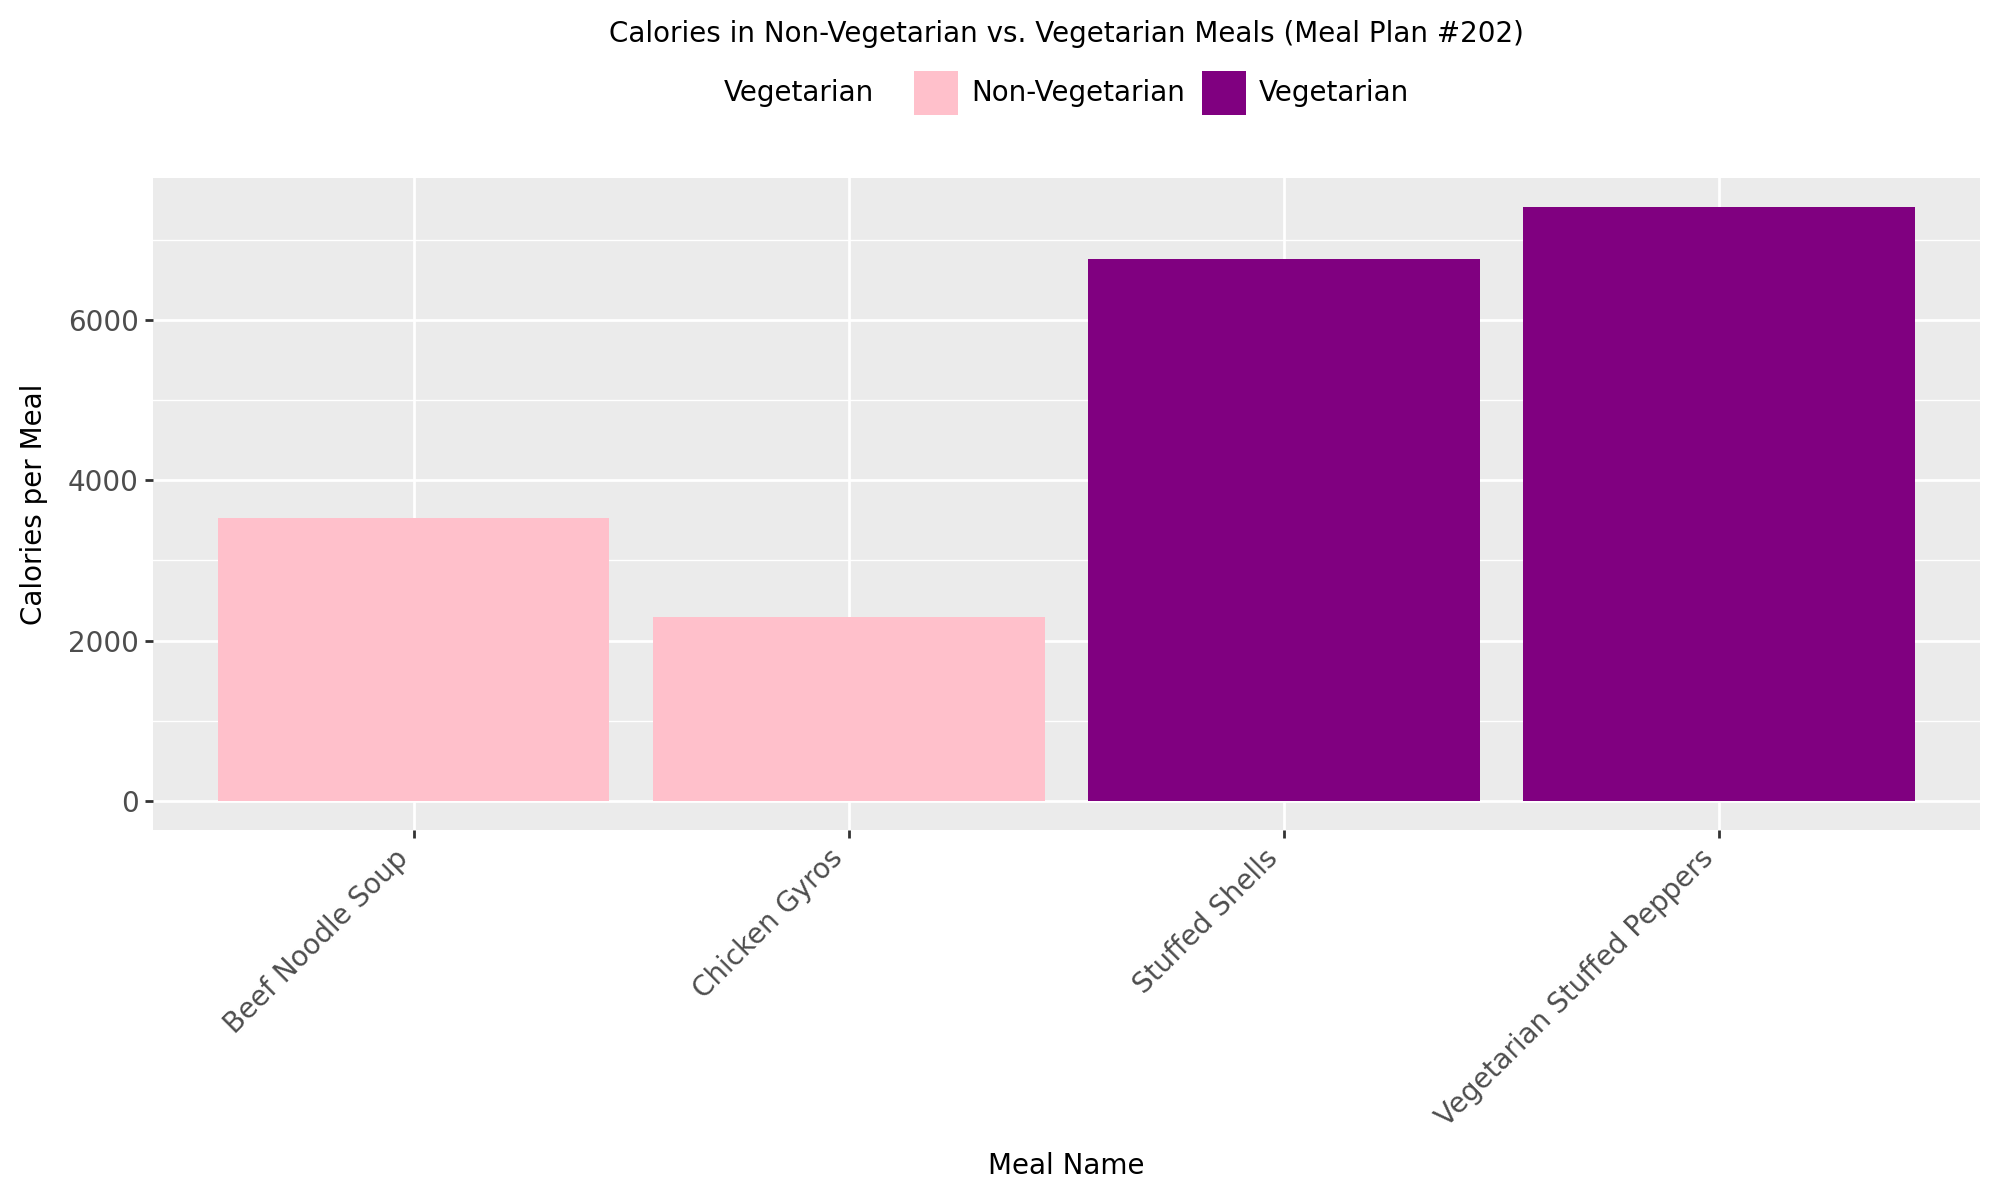

In [52]:
# Ensure df is cleaned for plotting (dropping NaNs in nutritional columns)
df_cleaned_202 = df.dropna(subset=['Calories', 'Protein', 'Carbs', 'Fat']).copy()

# Plot 1: Calories in Vegetarian vs Non-Vegetarian Meals for Meal Plan #202
plot_calories_202 = (
    ggplot(df_cleaned_202, aes(x="Meal Name", y="Calories", fill="Vegetarian"))
    + geom_bar(stat="identity")
    + scale_fill_manual(values={"Vegetarian": "purple", "Non-Vegetarian": "pink"})
    + labs(
        title="Calories in Non-Vegetarian vs. Vegetarian Meals (Meal Plan #202)",
        x="Meal Name",
        y="Calories per Meal",
        fill="Vegetarian"
    )
    + theme(
        figure_size=(10, 6),
        axis_text_x=element_text(rotation=45, ha="right"),
        text=element_text(size=10),
        legend_position="top"
    )
)
display(plot_calories_202)

### Protein and Carbohydrate Content by Meal (Meal Plan #202)

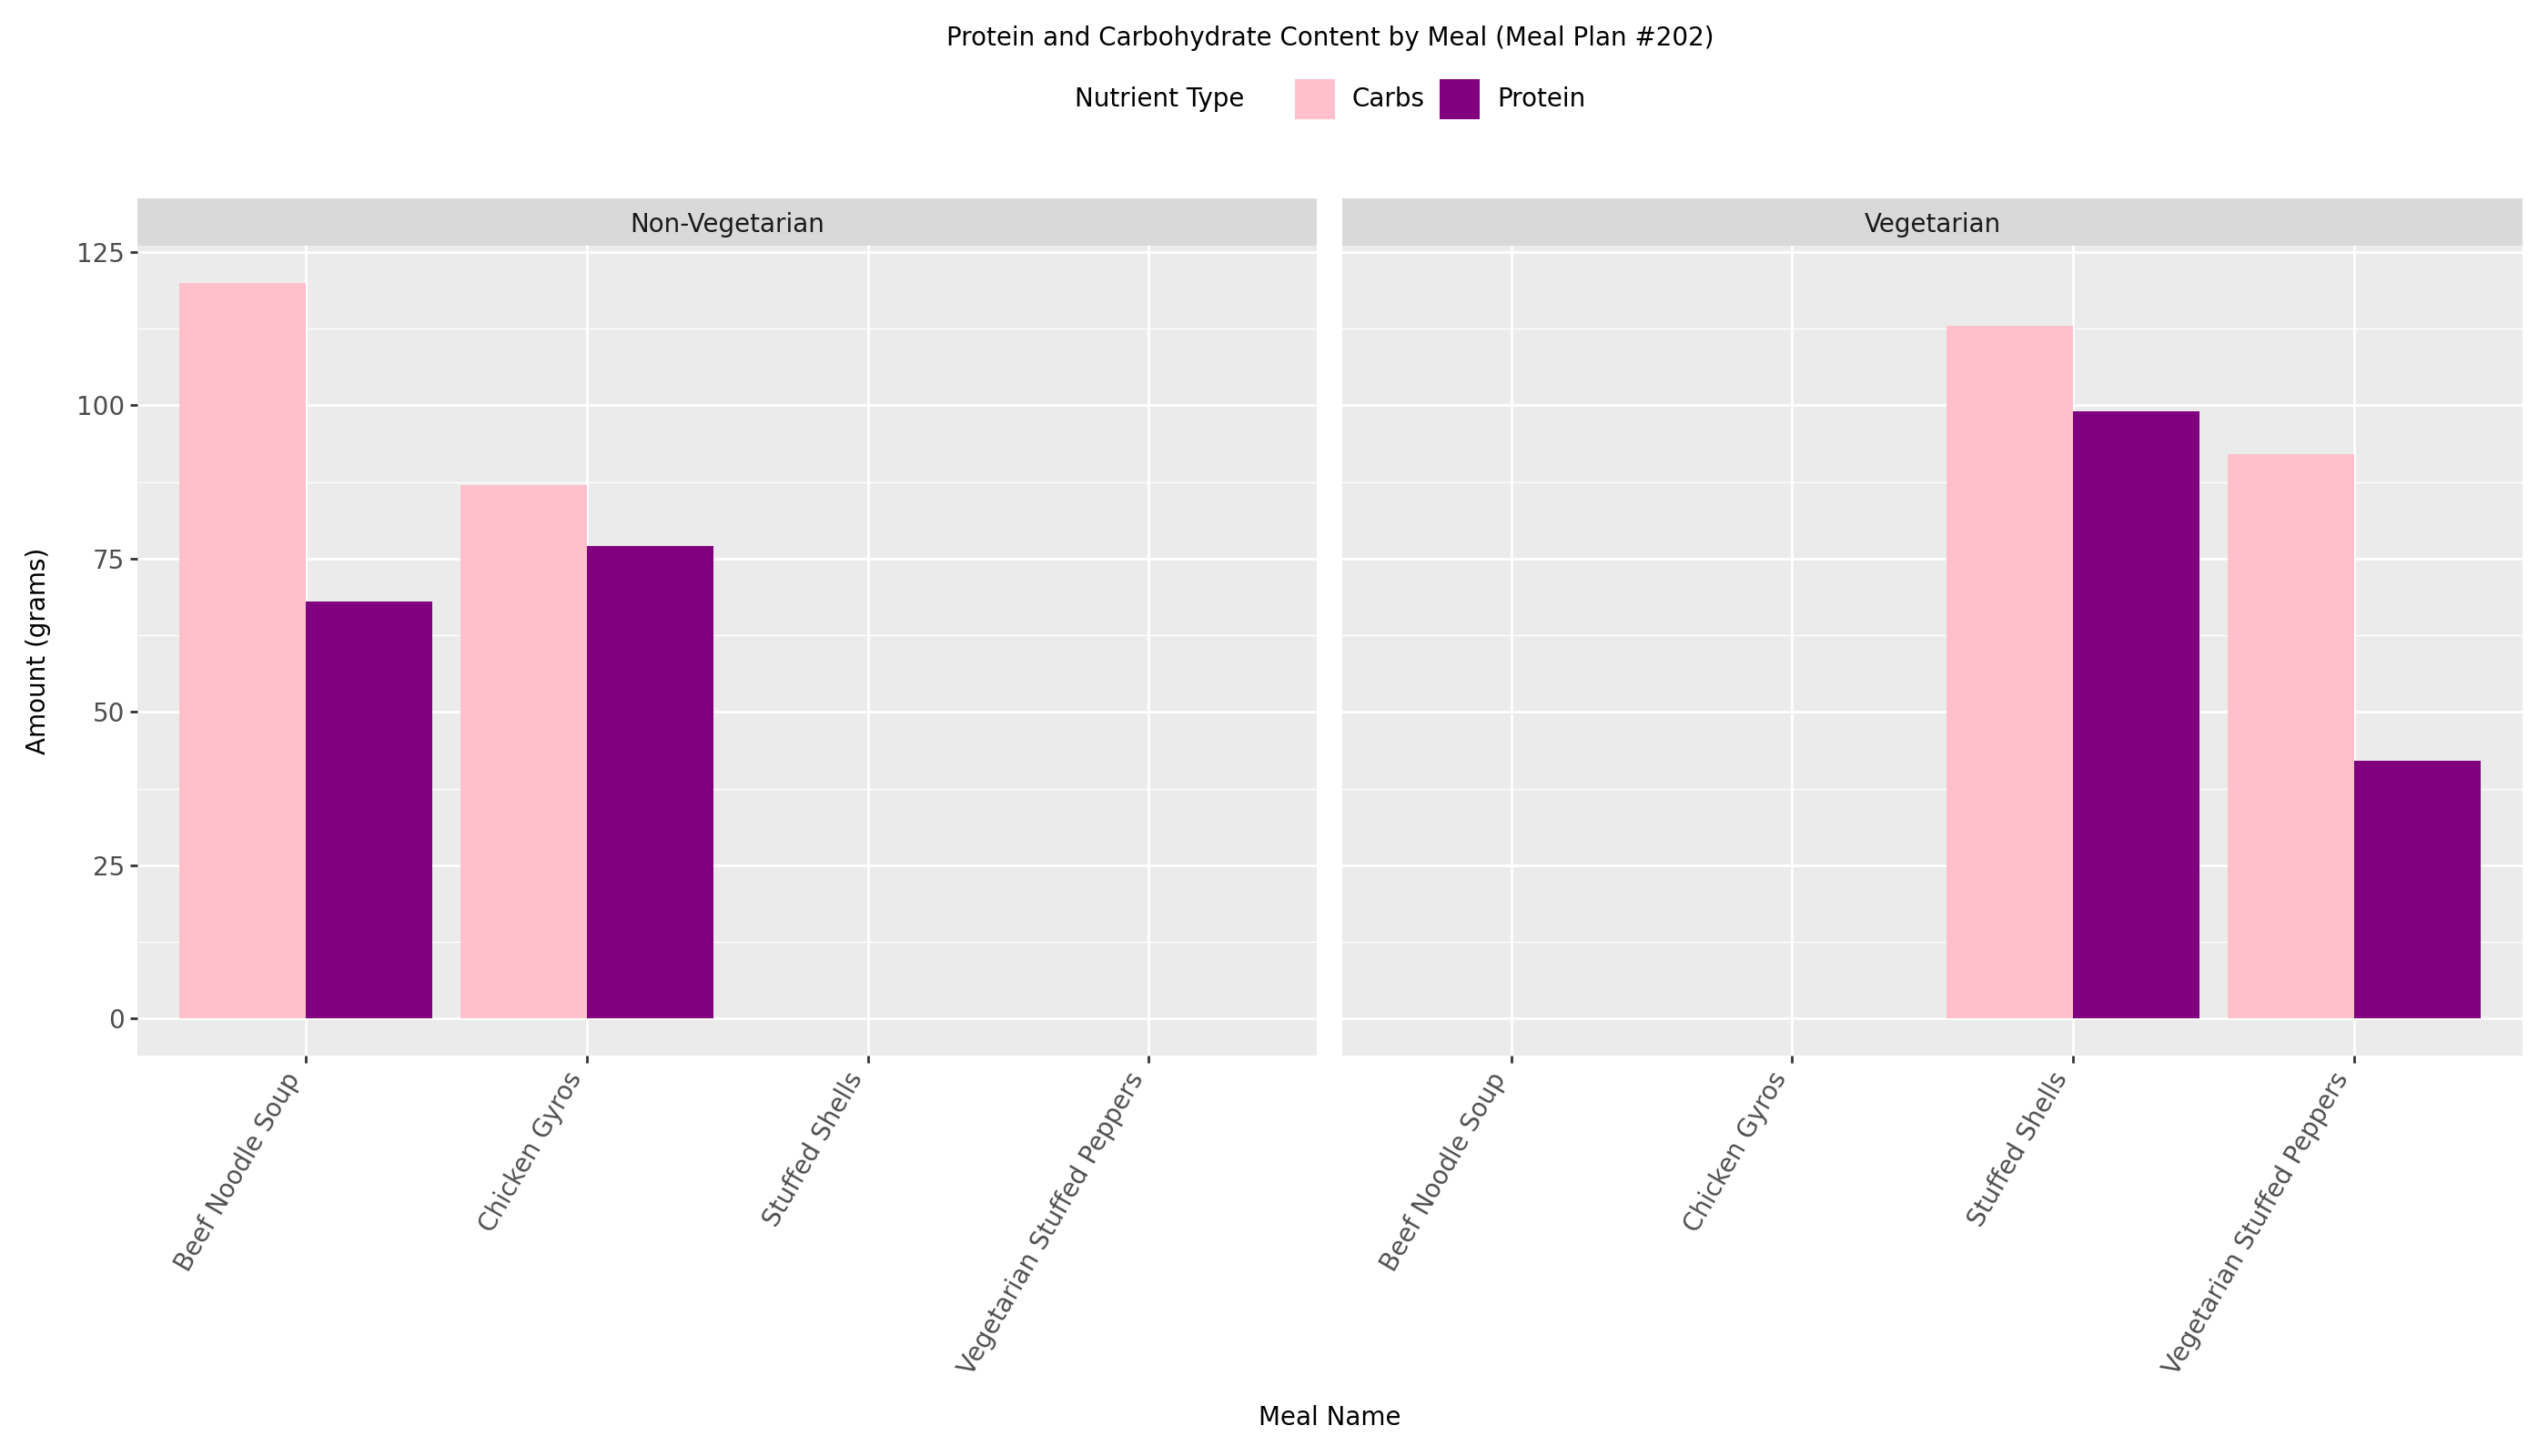

In [54]:
# Select relevant columns for plotting nutritional data
df_nutrition_plot_202 = df_cleaned_202[['Day', 'Meal Name', 'Vegetarian', 'Protein', 'Carbs']].copy()

# Melt the DataFrame to transform 'Protein' and 'Carbs' columns into row values
df_melted_202 = pd.melt(df_nutrition_plot_202,
                    id_vars=['Day', 'Meal Name', 'Vegetarian'],
                    value_vars=['Protein', 'Carbs'],
                    var_name='Nutrient Type',
                    value_name='Amount')

# Create the grouped bars
plot_nutrition_202 = (
    ggplot(df_melted_202, aes(x='Meal Name', y='Amount', fill='Nutrient Type'))
    + geom_bar(stat='identity', position='dodge') # Use 'dodge' to place bars side-by-side
    + scale_fill_manual(values={'Protein': 'purple', 'Carbs': 'pink'})
    + facet_wrap('~ Vegetarian') # Create separate plots for 'Vegetarian' and 'Non-Vegetarian' meals
    + labs(
        title="Protein and Carbohydrate Content by Meal (Meal Plan #202)",
        x="Meal Name",
        y="Amount (grams)",
        fill="Nutrient Type"
    )
    + theme(
        figure_size=(14, 8), # Adjust figure size for better readability
        axis_text_x=element_text(rotation=60, ha='right'), # Rotate x-axis labels
        text=element_text(size=10),
        legend_position="top"
    )
)
display(plot_nutrition_202)

# Meal #111

# Key takeaway

In [47]:
# Get detailed data for Meal Plan 111
df_111_detailed = get_mealplan_data(111)

# Get detailed data for Meal Plan 202
df_202_detailed = get_mealplan_data(202)

# Add a 'Meal Plan' column to distinguish between the two plans
df_111_detailed['Meal Plan'] = 111
df_202_detailed['Meal Plan'] = 202

# Select all initial relevant columns before sorting and final filtering
initial_comparison_columns = [
    'Meal Plan', 'Day', 'Meal Name', 'Tasty Recipe Name', 'Number of Ingredients',
    'Cook Time (min)', 'Meal Time of Day', 'Calories', 'Protein', 'Carbs', 'Fat'
]

df_comparison = pd.concat([
    df_111_detailed[initial_comparison_columns],
    df_202_detailed[initial_comparison_columns]
])
df_comparison = df_comparison.dropna()

# Define the desired columns for the final output
desired_output_columns = [
    'Meal Plan',
    'Meal Name',
    'Number of Ingredients',
    'Cook Time (min)',
    'Meal Time of Day',
    'Calories',
    'Protein',
    'Carbs',
    'Fat'
]

# Sort the df_comparison by 'Cook Time (min)' and select only the desired columns
df_comparison = df_comparison[desired_output_columns].sort_values(by='Cook Time (min)', ascending=True).reset_index(drop=True)

# Define a helper function to format cook time
def format_cook_time(minutes):
    if pd.isna(minutes):
        return None
    minutes = int(minutes)
    if minutes >= 60:
        hours = minutes // 60
        remaining_minutes = minutes % 60
        parts = []
        if hours > 0:
            parts.append(f"{hours} hour{'s' if hours > 1 else ''}")
        if remaining_minutes > 0:
            parts.append(f"{remaining_minutes} minute{'s' if remaining_minutes > 1 else ''}")

        if not parts:
            return "0 minutes" # Should not happen if minutes >= 60
        elif len(parts) == 1:
            return parts[0]
        else:
            return f"{parts[0]} and {parts[1]}"
    else:
        return f"{minutes} minutes"

# Apply the formatting function to the 'Cook Time (min)' column
df_comparison['Cook Time (min)'] = df_comparison['Cook Time (min)'].apply(format_cook_time)

# Display the sorted and filtered comparison DataFrame
display(df_comparison.head(94))

5 meals in Meal Plan #111

Querying for: Turkey Chili
API Response Status: 200
Number of results from API: 40
First API result name: Turkey Chili

Querying for: Skillet Lasagna
API Response Status: 200
Number of results from API: 15
First API result name: Lasagna Skillet Pasta

Querying for: Pollo Fundido
API Response Status: 200
Number of results from API: 0

Querying for: Creamy Tomato and Spinach Tortellini
API Response Status: 200
Number of results from API: 0

Querying for: Pot Roast
API Response Status: 200
Number of results from API: 40
First API result name: The Best Ever Slow Cooker Pot Roast
5 meals in Meal Plan #202

Querying for: Chicken Divan
API Response Status: 200
Number of results from API: 0

Querying for: Beef Noodle Soup
API Response Status: 200
Number of results from API: 7
First API result name: Taiwanese Beef Noodle Soup

Querying for: Stuffed Shells
API Response Status: 200
Number of results from API: 28
First API result name: Enchilada-inspired Stuffed Shells



,Meal Plan,Meal Name,Number of Ingredients,Cook Time (min),Meal Time of Day,Calories,Protein,Carbs,Fat
0,111,Skillet Lasagna,14.0,0 minutes,"Dinner, Meal",847.0,59.0,66.0,40.0
1,111,Turkey Chili,18.0,0 minutes,"Dinner, Meal",178.0,16.0,11.0,7.0
2,111,Pot Roast,17.0,0 minutes,"Dinner, Meal",304.0,16.0,13.0,20.0
3,111,Pot Roast,12.0,0 minutes,"Dinner, Meal",304.0,33.0,6.0,16.0
4,202,Vegetarian Stuffed Peppers,17.0,0 minutes,"Dinner, Meal",383.0,16.0,48.0,14.0
5,111,Turkey Chili,17.0,23 minutes,"Dinner, Meal",447.0,20.0,4.0,38.0
6,202,Chicken Gyros,19.0,28 minutes,"Dinner, Lunch",785.0,77.0,87.0,14.0
7,111,Pot Roast,6.0,30 minutes,"Dinner, Lunch, Sides",268.0,2.0,39.0,11.0
8,111,Pot Roast,6.0,30 minutes,Sides,90.0,1.0,15.0,3.0
9,111,Turkey Chili,7.0,30 minutes,"Breakfast, Brunch",90.0,10.0,0.0,4.0


In [56]:
df_comparison.groupby('Meal Plan')[['Calories', 'Protein', 'Carbs']].mean().round(1)

,Calories,Protein,Carbs
Meal Plan,,,
111,472.0,31.1,37.7
202,559.6,29.4,52.4


## Final Comparison

Meal Plan 111 seems a little more balanced overall because it has lower average calories and carbs, while still having slightly higher protein. Meal Plan 202 has more variety in the cleaned results, but some meals are heavier, especially Beef Noodle Soup and Stuffed Shells.

In terms of time, both plans have quick and long options. Chicken Gyros stood out to me because it had strong protein and some reasonable cook-time options, so it feels like one of the more practical meals. 

The calorie plot showed that vegetarian meals were not always lower in calories. Stuffed Shells and Vegetarian Stuffed Peppers still had higher-calorie matches, likely because many matched recipes involved filling ingredients like pasta, cheese, quinoa, or stuffed fillings.

The protein/carbohydrate plot showed that Chicken Gyros was a stronger protein option, while the vegetarian meals leaned more carb-heavy ratio. Honestly, I was surpised at the protein to carb ratio for the stuffed shells vegatarian option. I never considered them as an option before but I would like to try it now. Personally, I liked Chicken Gyros the most because it had almost enough protein to match the carbs. That is exactly what I would need after a heavy workout to maximize muscle mass without feeling bloated. 